# Import Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set()
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Dataset

In [46]:
# Load the Stress dataset
df = pd.read_csv("Stress Indicators Dataset for Mental Health Classification.csv")

# Display basic information
print("DATASET INFORMATION")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

DATASET INFORMATION
Rows: 2000
Columns: 26

Column names:
['gender', 'age', 'stress_experience', 'heartbeat_palpitations', 'anxiety_tension', 'sleep_problems', 'restlessness', 'headaches', 'irritability', 'concentration_problems', 'sadness_low_mood', 'health_issues', 'loneliness_isolation', 'academic_overload', 'peer_competition', 'relationship_stress', 'professor_difficulties', 'work_environment', 'lack_relaxation_time', 'home_environment', 'low_academic_confidence', 'subject_confidence', 'academic_conflicts', 'class_attendance', 'weight_changes', 'stress_type']


# View Data BEFORE Cleaning

In [62]:
print("DATA BEFORE CLEANING")

print("\nFirst 5 rows:")
print(df.head())

print(f"\nshape: {df.shape}")
print("\nData types:")
print(df.dtypes)

DATA BEFORE CLEANING

First 5 rows:
   gender  age  stress_experience  heartbeat_palpitations  anxiety_tension  \
0       1   20                  1                       2                2   
1       0   19                  4                       5                5   
2       0   21                  4                       2                3   
3       0   20                  1                       3                2   
4       0   19                  4                       3                3   

   sleep_problems  restlessness  headaches  irritability  \
0               4             3          1             4   
1               4             4          5             4   
2               3             4          4             1   
3               1             3          1             5   
4               2             3          4             2   

   concentration_problems  ...  professor_difficulties  work_environment  \
0                       5  ...                       2    

# Check for Missing Values

In [48]:
print("MISSING VALUES CHECK")

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found!")
else:
    print("\nMissing values found - we will clean them")

MISSING VALUES CHECK

Missing values per column:
gender                     0
age                        0
stress_experience          0
heartbeat_palpitations     0
anxiety_tension            0
sleep_problems             0
restlessness               0
headaches                  0
irritability               0
concentration_problems     0
sadness_low_mood           0
health_issues              0
loneliness_isolation       0
academic_overload          0
peer_competition           0
relationship_stress        0
professor_difficulties     0
work_environment           0
lack_relaxation_time       0
home_environment           0
low_academic_confidence    0
subject_confidence         0
academic_conflicts         0
class_attendance           0
weight_changes             0
stress_type                0
dtype: int64

Total missing values: 0

No missing values found!


# Check for Duplicate Rows

In [49]:
print("DUPLICATE ROWS CHECK")

duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nDuplicate rows found:")
    print(df[df.duplicated()])
else:
    print("\nNo duplicate rows found!")

DUPLICATE ROWS CHECK

Number of duplicate rows: 1191

Duplicate rows found:
      gender  age  stress_experience  heartbeat_palpitations  anxiety_tension  \
52         0   20                  2                       3                1   
60         0   20                  3                       2                1   
65         1   21                  4                       2                2   
71         0   19                  2                       3                2   
104        0   19                  3                       2                3   
...      ...  ...                ...                     ...              ...   
1995       1   19                  3                       2                2   
1996       0   20                  3                       4                4   
1997       0   15                  4                       3                2   
1998       0   18                  4                       2                1   
1999       1   20                

Duplicate Rows were found!!!!

# Clean the Data

In [50]:
print("DATA CLEANING")

rows_before = df.shape[0]

# Remove duplicates
df_clean = df.drop_duplicates()

# Remove rows with missing values
df_clean = df_clean.dropna()

rows_after = df_clean.shape[0]

print(f"\nRows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

DATA CLEANING

Rows before cleaning: 2000
Rows after cleaning: 809
Rows removed: 1191


I performed two main cleaning steps:

1. REMOVED DUPLICATE ROWS: I used .drop_duplicates() to remove any
   rows that were exact copies of each other.

2. REMOVED MISSING VALUES: I used .dropna() to remove any rows that
   had empty cells (missing answers).

Duplicate rows are a problem because:
   - They would count the same person multiple times
   - This would make statistics and averages inaccurate
   - For example, if one person's data appears twice, their answers would
     have double the influence on the results

Missing values are a problem because:
   - Calculations like averages cannot be performed on empty cells
   - It would cause errors when creating visualizations
   - Incomplete data cannot be used for accurate analysis

changes:
Before cleaning: 2000 rows,
After cleaning: 809 rows,
Rows removed: 1191 rows

This means 1191 rows were removed because they were either duplicates
of other rows or contained missing values. The remaining 809 rows are
complete and unique, ready for analysis.

The data types were already correct (all numbers are stored as integers),
so no changes were needed for data types.

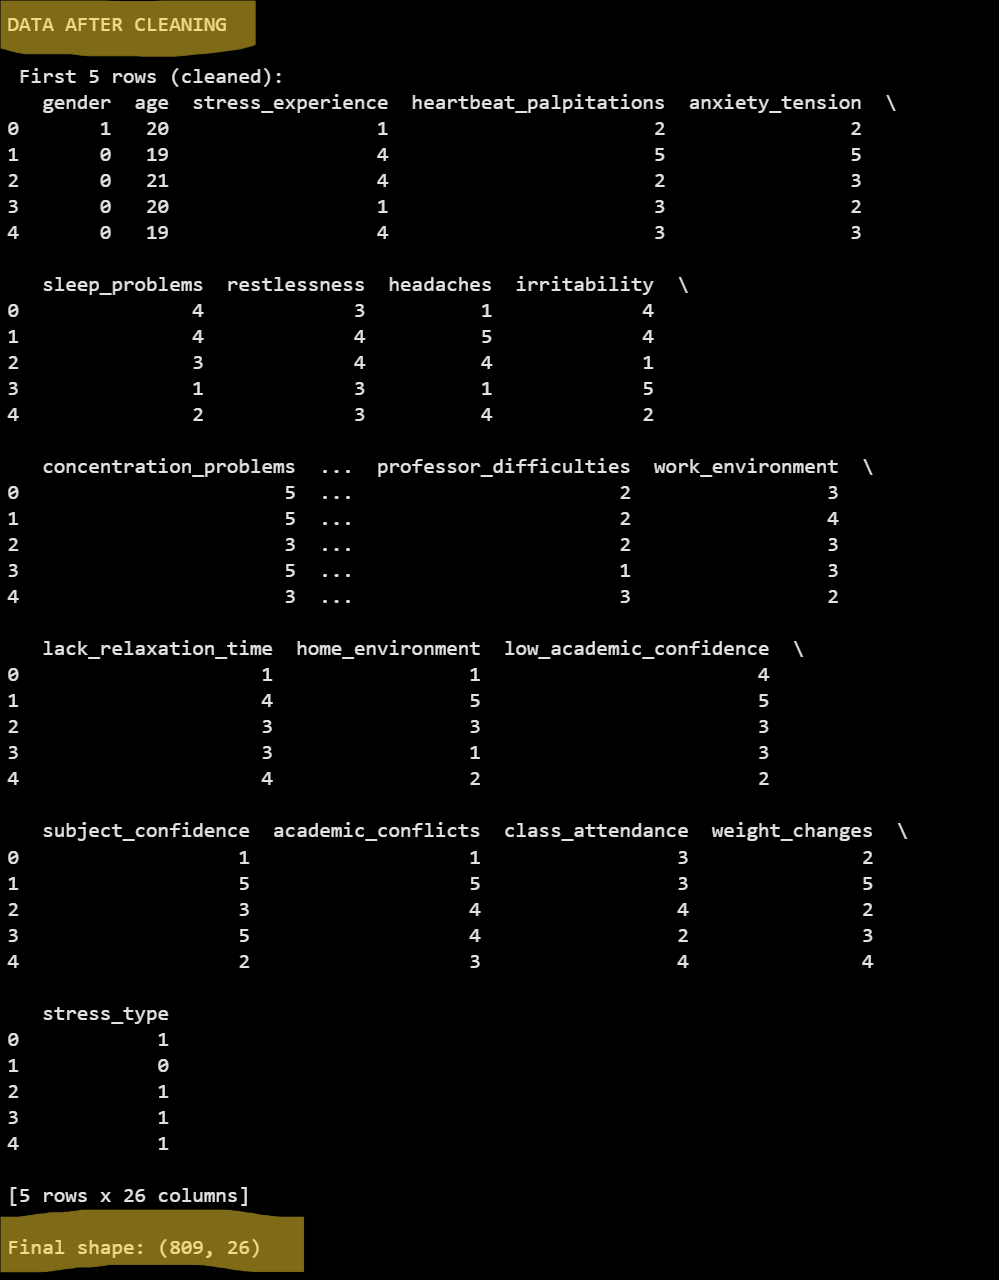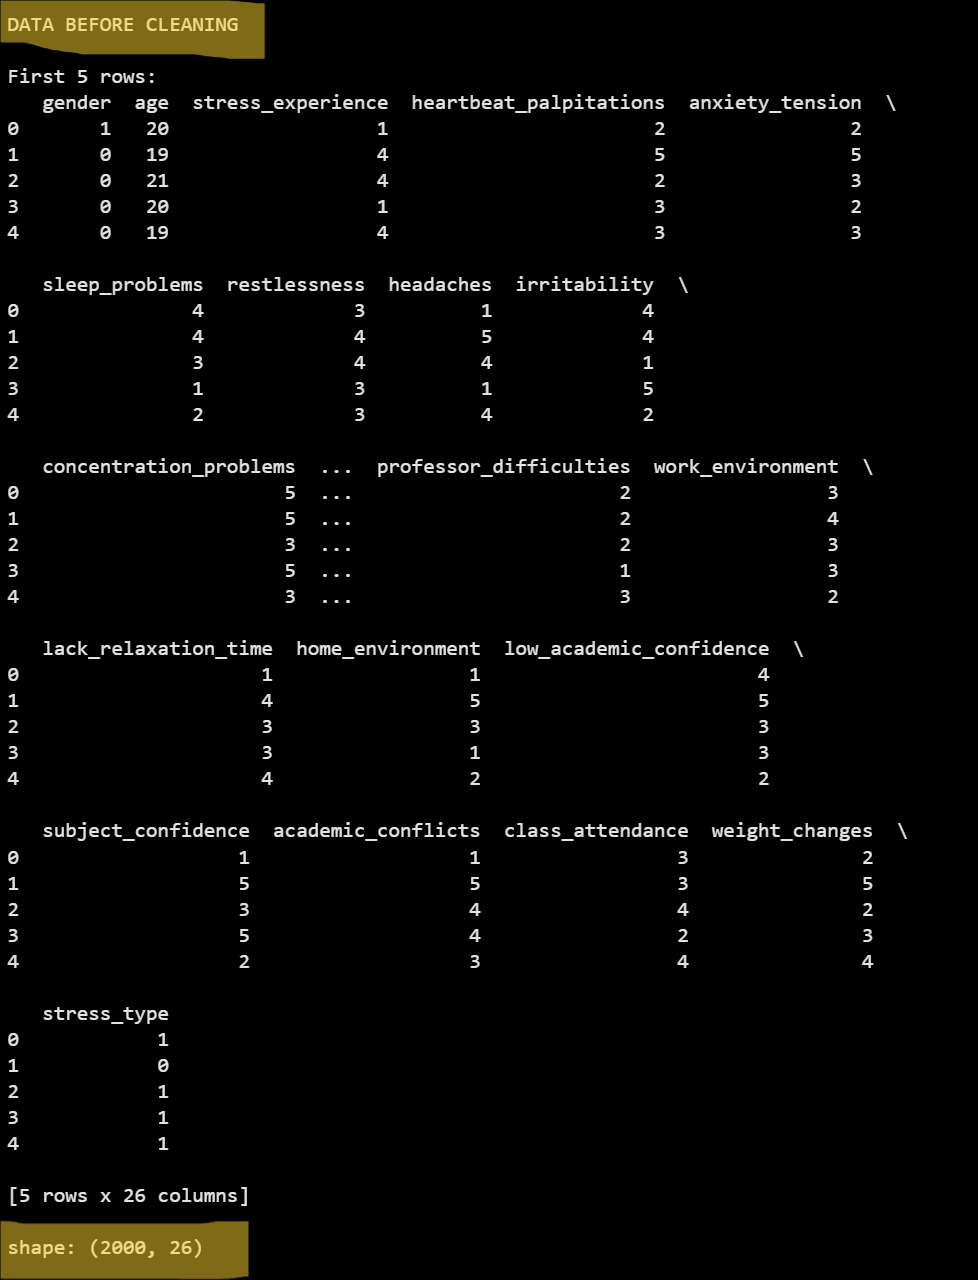

# View Data AFTER Cleaning

In [51]:
print("DATA AFTER CLEANING")

print("\n First 5 rows (cleaned):")
print(df_clean.head())

print(f"\nFinal shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

DATA AFTER CLEANING

 First 5 rows (cleaned):
   gender  age  stress_experience  heartbeat_palpitations  anxiety_tension  \
0       1   20                  1                       2                2   
1       0   19                  4                       5                5   
2       0   21                  4                       2                3   
3       0   20                  1                       3                2   
4       0   19                  4                       3                3   

   sleep_problems  restlessness  headaches  irritability  \
0               4             3          1             4   
1               4             4          5             4   
2               3             4          4             1   
3               1             3          1             5   
4               2             3          4             2   

   concentration_problems  ...  professor_difficulties  work_environment  \
0                       5  ...                  

# Statistical Summary

In [52]:
print("STATISTICAL SUMMARY")

print("\nDescription of numeric columns:")
print(df_clean.describe())

STATISTICAL SUMMARY

Description of numeric columns:
           gender         age  stress_experience  heartbeat_palpitations  \
count  809.000000  809.000000         809.000000              809.000000   
mean     0.358467   20.088999           3.012361                2.754017   
std      0.479847    5.535394           1.123487                1.116954   
min      0.000000   14.000000           1.000000                1.000000   
25%      0.000000   19.000000           2.000000                2.000000   
50%      0.000000   19.000000           3.000000                3.000000   
75%      1.000000   20.000000           4.000000                4.000000   
max      1.000000  100.000000           5.000000                5.000000   

       anxiety_tension  sleep_problems  restlessness   headaches  \
count       809.000000      809.000000    809.000000  809.000000   
mean          2.533993        2.786156      2.660074    2.626700   
std           1.206067        1.248764      1.265263    1.

# PLOT 1: Distribution of Stress Experience

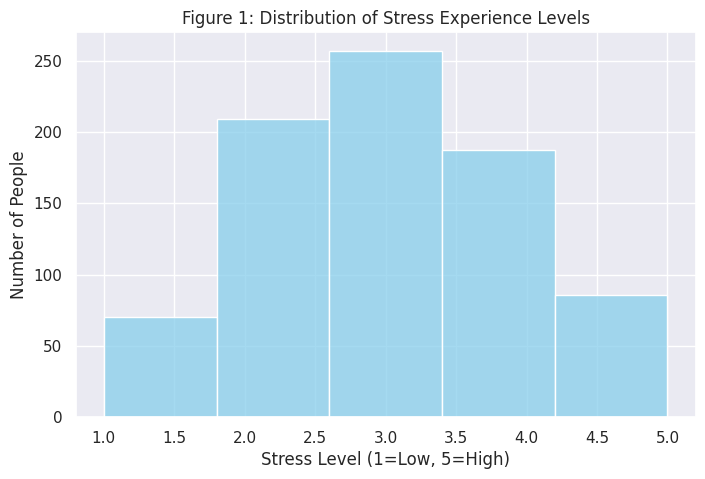

In [64]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['stress_experience'], bins=5, color='skyblue')
plt.title('Figure 1: Distribution of Stress Experience Levels')
plt.xlabel('Stress Level (1=Low, 5=High)')
plt.ylabel('Number of People')
plt.show()


A histogram is the best way to see how a single measurement (like stress level) is spread across many people. It groups people by their answers so we can see the most common response at a glance.

Main Insights:
The tallest bar shows that the most common stress level is 3 (medium)

We can learn whether this group of people generally experiences low, medium, or high levels of stress.

# PLOT 2: Stress Type Distribution

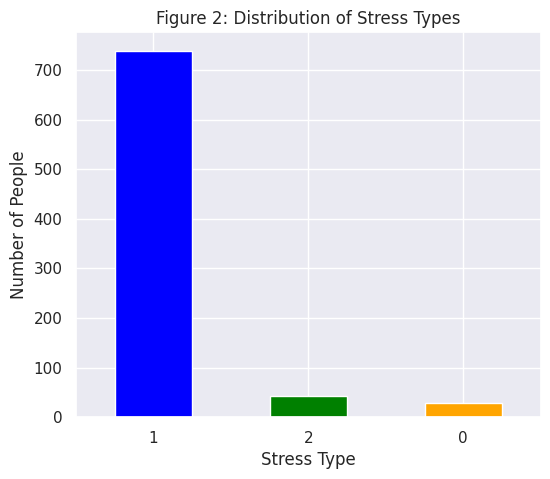

In [66]:
plt.figure(figsize=(6, 5))
stress_counts = df_clean['stress_type'].value_counts()
stress_counts.plot(kind='bar', color=['blue', 'green', 'orange', 'red'][:len(stress_counts)])
plt.title('Figure 2: Distribution of Stress Types')
plt.xlabel('Stress Type')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.show()


A bar chart is perfect for showing how many people fall into different categories. It's easy to compare the heights of the bars.

Main Insights:
stress type 1 people dominate the chart

We can learn the proportion of people in each stress category, which tells us if high stress is common or rare in this population.

# PLOT 3: Age Distribution

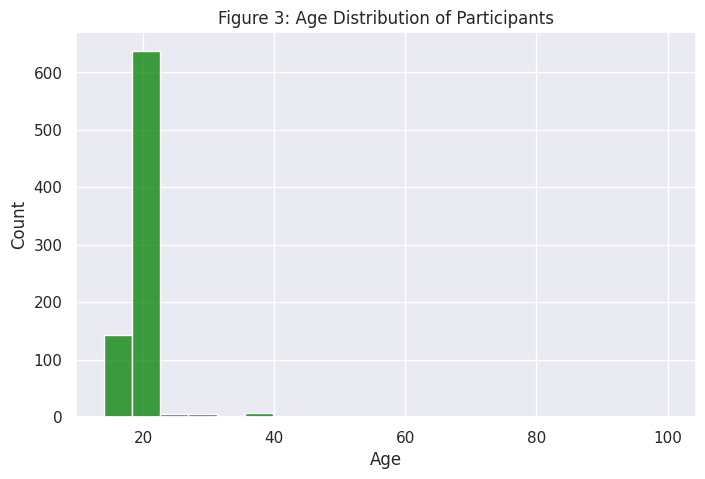

In [55]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['age'], bins=20, color='green')
plt.title('Figure 3: Age Distribution of Participants')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


A histogram shows us the age range of our participants. This helps us understand what age groups are represented in our data.

Main Insights:
that's the most common age group in our study are the 20s.

We can learn who this data represents and are these teenagers, college students, working adults? This helps us understand who the findings apply to

# PLOT 4: Sleep Problems vs Stress Type

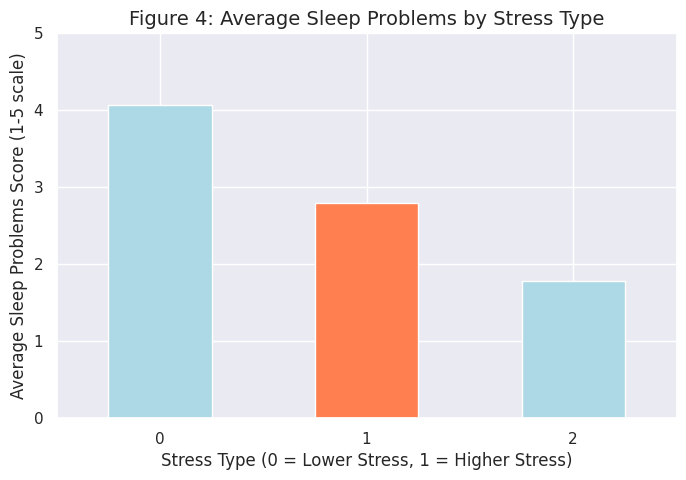

In [56]:
plt.figure(figsize=(8, 5))

# Calculate average sleep problems for each stress type
avg_sleep = df_clean.groupby('stress_type')['sleep_problems'].mean()

# Create bar chart
colors = ['lightblue', 'coral']
avg_sleep.plot(kind='bar', color=colors)

plt.title('Figure 4: Average Sleep Problems by Stress Type', fontsize=14)
plt.xlabel('Stress Type (0 = Lower Stress, 1 = Higher Stress)', fontsize=12)
plt.ylabel('Average Sleep Problems Score (1-5 scale)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.show()


A bar chart comparing averages is the clearest way to show if
   two groups differ.

Patterns observed:
   If the red bar (higher stress) is taller than the blue bar
   (lower stress), this suggests that stress and sleep problems
   are related if not then its the opposite.

   This tells us whether sleep problems are more common in people
   who report higher stress. If yes, improving sleep might help
   reduce stress, or reducing stress might improve sleep

# PLOT 5: Anxiety by Gender

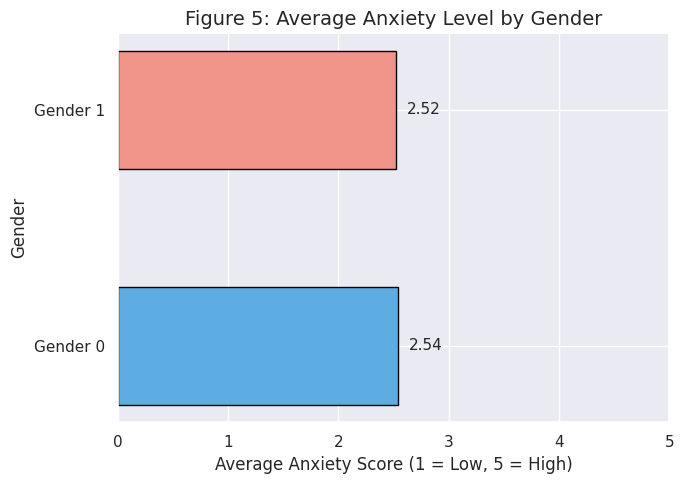

In [57]:
plt.figure(figsize=(7, 5))

# Calculate average anxiety for each gender
avg_anxiety = df_clean.groupby('gender')['anxiety_tension'].mean()

# Create horizontal bar chart
colors = ['#5DADE2', '#F1948A']
plt.barh([0, 1], avg_anxiety, color=colors, edgecolor='black', height=0.5)

plt.title('Figure 5: Average Anxiety Level by Gender', fontsize=14)
plt.ylabel('Gender', fontsize=12)
plt.xlabel('Average Anxiety Score (1 = Low, 5 = High)', fontsize=12)
plt.yticks([0, 1], ['Gender 0', 'Gender 1'])
plt.xlim(0, 5)

# Add value labels on the bars
for i, v in enumerate(avg_anxiety):
    plt.text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

I chose a horizontal bar chart because it makes it very easy to compare the average anxiety scores between the two gender groups.

Main insights:
The bar for Gender 0 is longer, meaning this group reports higher average anxiety

The exact average scores are shown on the bars: 2.54 for Gender 0 and 2.52 for Gender 1

This visualization helps us understand whether anxiety is experienced differently across genders. If one gender shows consistently higher anxiety scores, this could indicate that different support strategies or resources might be needed for different groups.

# PLOT 6: Loneliness vs Age

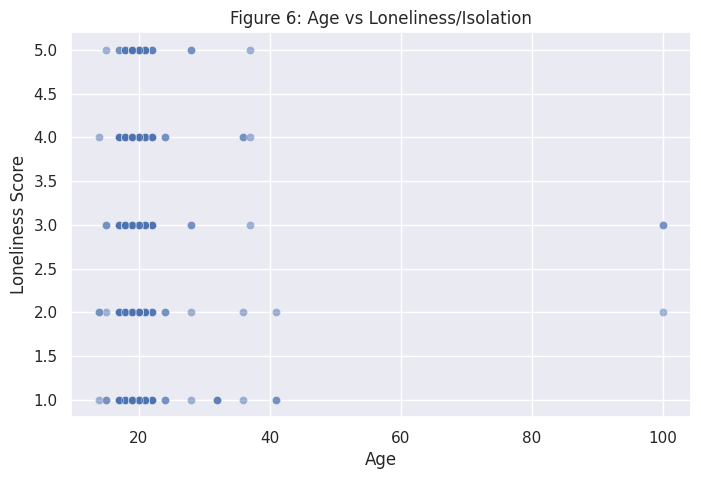

In [58]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='loneliness_isolation', data=df_clean, alpha=0.5)
plt.title('Figure 6: Age vs Loneliness/Isolation')
plt.xlabel('Age')
plt.ylabel('Loneliness Score')
plt.show()


A scatter plot shows the relationship between two numbers. Each dot is one person, showing their age and loneliness score.

Main Insights:
If dots go up as age increases → loneliness increases with age

If dots go down as age increases → loneliness decreases with age

If dots are scattered randomly → no relationship

notice whether loneliness is related to age. This could tell us if certain age groups need more support.

# PLOT 7: Correlation Heatmap- How Symptoms Relate

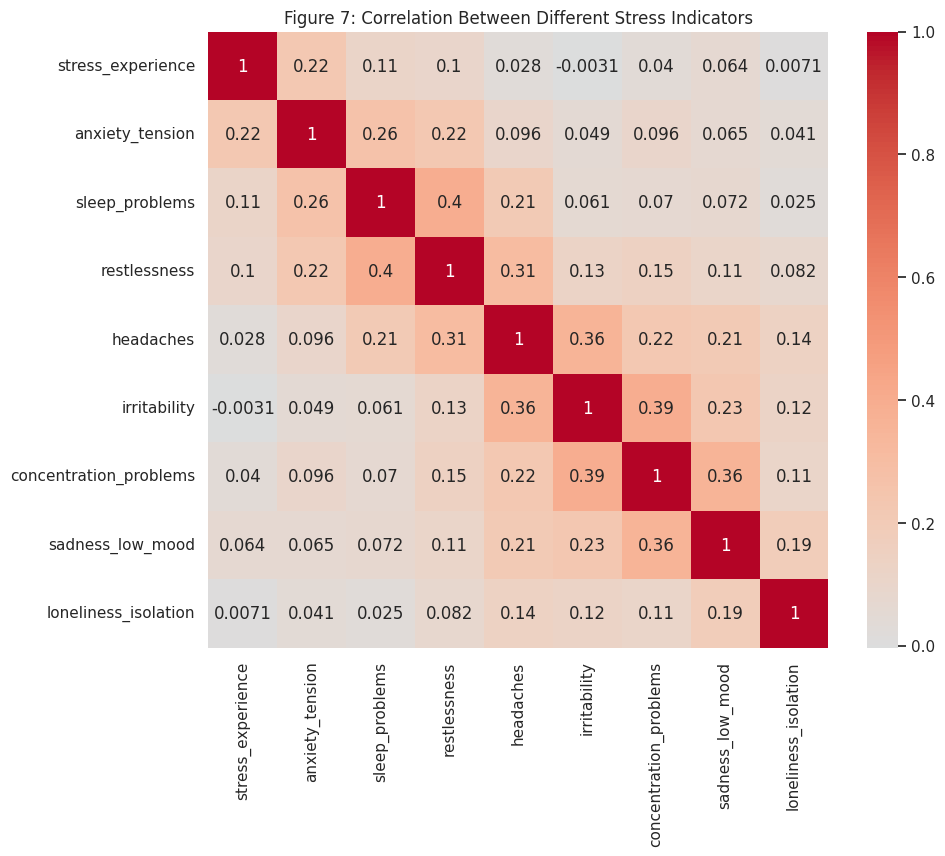

In [59]:
# Select numeric columns for correlation
numeric_cols = ['stress_experience', 'anxiety_tension', 'sleep_problems',
                'restlessness', 'headaches', 'irritability', 'concentration_problems',
                'sadness_low_mood', 'loneliness_isolation']

plt.figure(figsize=(10, 8))
corr_matrix = df_clean[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Figure 7: Correlation Between Different Stress Indicators')
plt.show()


A correlation heatmap uses colors to show which symptoms tend to happen together.the darker the color that means two symptoms are strongly related.
For example,anxiety and sleep problems

We can see which stress indicators are most connected. This helps identify what symptoms often occur together

# PLOT 8: Average of All Stress Indicators

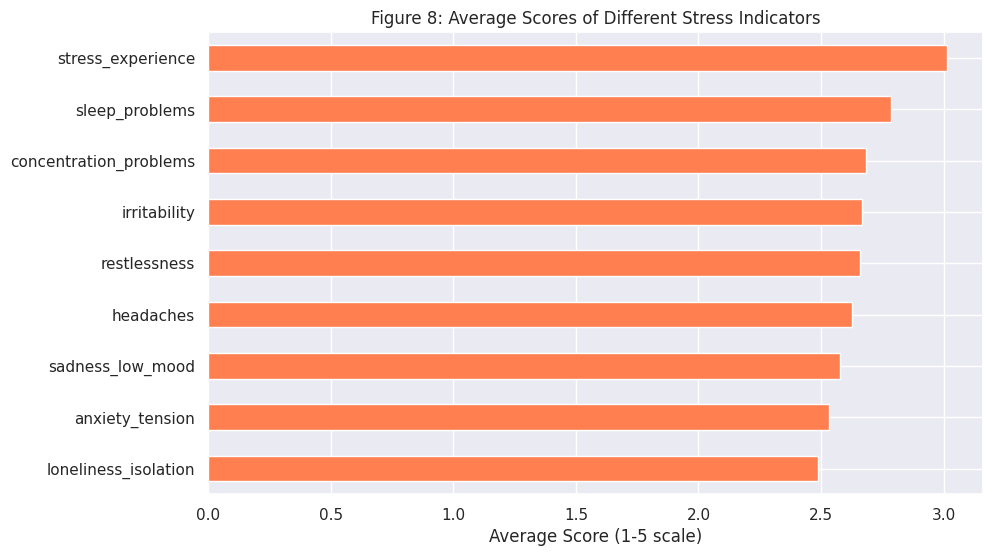

In [60]:
# Calculate averages of key indicators
indicators = ['stress_experience', 'anxiety_tension', 'sleep_problems',
              'restlessness', 'headaches', 'irritability', 'concentration_problems',
              'sadness_low_mood', 'loneliness_isolation']

avg_scores = df_clean[indicators].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_scores.plot(kind='barh', color='coral')
plt.title('Figure 8: Average Scores of Different Stress Indicators')
plt.xlabel('Average Score (1-5 scale)')
plt.show()


A horizontal bar chart ranked from highest to lowest makes it easy to see which symptoms are most common and which are least common.

Main Insights:
The top symptom is stress experience  and the
loneliness isolation has the lowest average score
You can see at a glance what the biggest problems are

This tells us what to focus on when helping people manage stress.